In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("50_startups.csv")

In [3]:
dataset

,R&D Spend,Administartion,Mrketing Spend,State,Profit
0,165616,165754,41479,New York,19683
1,165026,165062,54009,California,17942
2,165192,165584,43133,California,15659
3,165026,165738,51609,New York,19604
4,165264,165011,46877,California,22525
5,165193,165165,43990,California,21121
6,165478,165880,50919,California,24060
7,165732,165208,40310,California,21456
8,165292,165761,54439,New York,20967
9,165480,165878,52484,California,17102


In [5]:
dataset = pd.get_dummies(dataset).astype(int)

In [6]:
dataset

,R&D Spend,Administartion,Mrketing Spend,Profit,State_California,State_New York
0,165616,165754,41479,19683,0,1
1,165026,165062,54009,17942,1,0
2,165192,165584,43133,15659,1,0
3,165026,165738,51609,19604,0,1
4,165264,165011,46877,22525,1,0
5,165193,165165,43990,21121,1,0
6,165478,165880,50919,24060,1,0
7,165732,165208,40310,21456,1,0
8,165292,165761,54439,20967,0,1
9,165480,165878,52484,17102,1,0


In [7]:
dataset.columns

Index(['R&D Spend', 'Administartion', 'Mrketing Spend', 'Profit',
       'State_California', 'State_New York'],
      dtype='object')

In [8]:
independent = dataset[['R&D Spend', 'Administartion', 'Mrketing Spend',
       'State_New York']]

In [9]:
independent

,R&D Spend,Administartion,Mrketing Spend,State_New York
0,165616,165754,41479,1
1,165026,165062,54009,0
2,165192,165584,43133,0
3,165026,165738,51609,1
4,165264,165011,46877,0
5,165193,165165,43990,0
6,165478,165880,50919,0
7,165732,165208,40310,0
8,165292,165761,54439,1
9,165480,165878,52484,0


In [10]:
dependent = dataset[['Profit']]

In [11]:
dependent

,Profit
0,19683
1,17942
2,15659
3,19604
4,22525
5,21121
6,24060
7,21456
8,20967
9,17102


In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(independent, dependent,test_size=0.30,random_state=0)

In [44]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='poisson', splitter='best')
regressor.fit(X_train,Y_train)

,criterion,'poisson'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


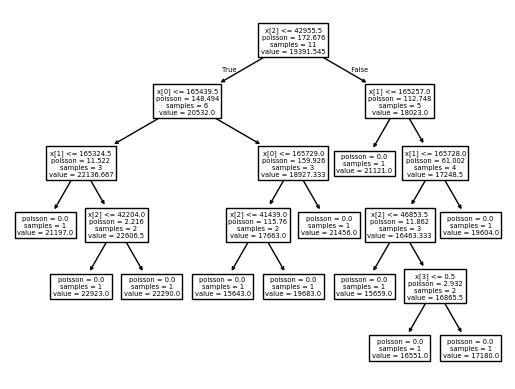

In [45]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [46]:
y_pred=regressor.predict(X_test)

In [47]:
from sklearn.metrics import r2_score
r2_score=r2_score(Y_test,y_pred)
r2_score

-0.018082292096474717

In [48]:
r2_score

-0.018082292096474717